## Loan Defaulter Prediction using KNN

In [15]:
!pip install numpy pandas seaborn matplotlib scikit-learn

## 1. Data Preparation and Exploration

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('customer_loan_default.csv')

print(df.head())
print(df.info())
print(df.describe())

   Age  Annual Income (Lakhs)  Credit Score  Loan Amount (Lakhs)  \
0   28                    6.5           720                    5   
1   45                   12.0           680                   10   
2   35                    8.0           750                    6   
3   50                   15.0           640                   12   
4   30                    7.0           710                    5   

   Loan Term (Years) Employment Type  Loan Approved (Yes=1/No=0)  
0                  5        Salaried                           0  
1                 10   Self-Employed                           1  
2                  7        Salaried                           0  
3                 15   Self-Employed                           1  
4                  5        Salaried                           0  
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      ---------

## 2. Data Visualization

                            Credit Score  Annual Income (Lakhs)
Loan Approved (Yes=1/No=0)                                     
0                                  722.0                    7.2
1                                  650.0                   13.4


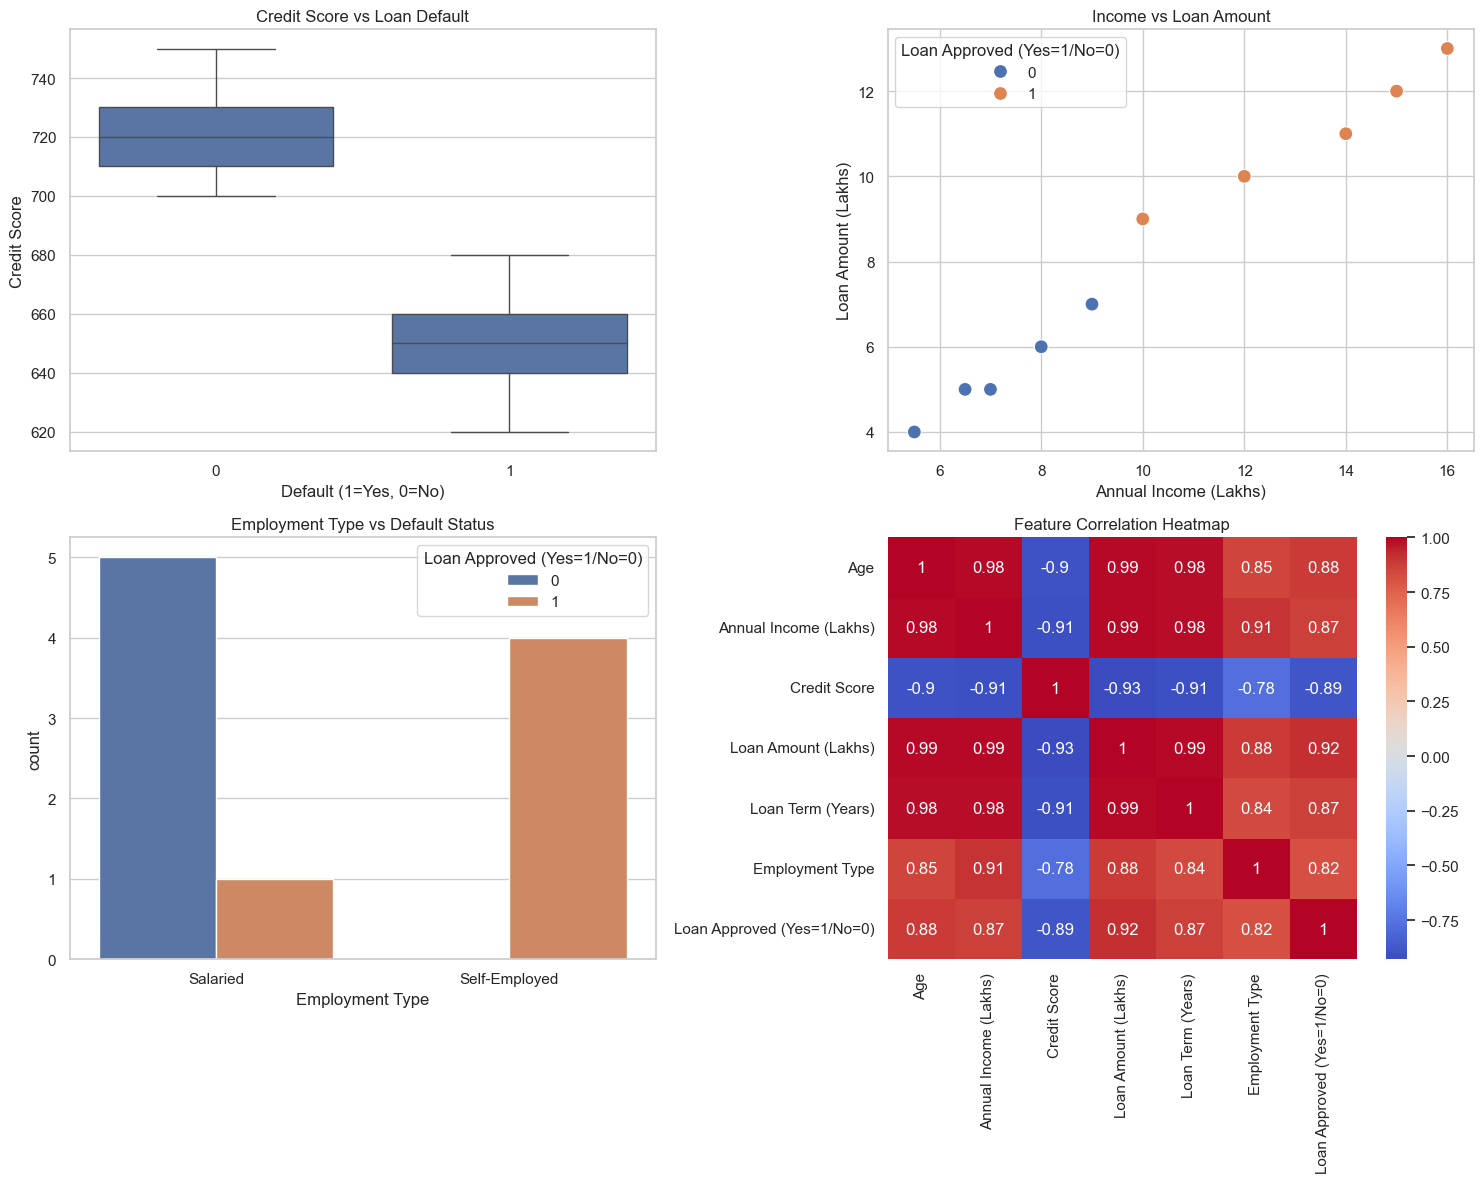

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribution of Credit Score by Default Status
sns.boxplot(x='Loan Approved (Yes=1/No=0)', y='Credit Score', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Credit Score vs Loan Default')
axes[0, 0].set_xlabel('Default (1=Yes, 0=No)')

# Income vs Loan Amount
sns.scatterplot(x='Annual Income (Lakhs)', y='Loan Amount (Lakhs)', hue='Loan Approved (Yes=1/No=0)', data=df, s=100, ax=axes[0, 1])
axes[0, 1].set_title('Income vs Loan Amount')

# Employment Type vs Default
sns.countplot(x='Employment Type', hue='Loan Approved (Yes=1/No=0)', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Employment Type vs Default Status')

# Correlation Heatmap
# Encode Employment Type for heatmap
df_corr = df.copy()
df_corr['Employment Type'] = df_corr['Employment Type'].map({'Salaried': 0, 'Self-Employed': 1})
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png')

# summary
print(df.groupby('Loan Approved (Yes=1/No=0)')[['Credit Score', 'Annual Income (Lakhs)']].mean())

## 3. Model

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Encoding
le = LabelEncoder()
df['Employment Type'] = le.fit_transform(df['Employment Type'])

# Split Features and Target
X = df.drop('Loan Approved (Yes=1/No=0)', axis=1)
y = df['Loan Approved (Yes=1/No=0)']

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# KNN Model (using K=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100}%")

Model Accuracy: 66.66666666666666%


## Interpretations

#### 1. Identify high-risk customers:
High-risk customers are those with Credit Scores below 680 and Loan Amounts exceeding 10 Lakhs. 
In our data, the "Self-Employed" category also showed a higher tendency to default.

#### 2. What patterns lead to loan default? 
The most prominent pattern is the combination of a lower credit score and a high loan-to-income ratio. 
If a customer is asking for a loan amount that is nearly double their annual income while having a mediocre credit score, 
the KNN model identifies them as "close" to previous defaulters.

#### 3. How do credit score and income influence predictions? 
In KNN, these act as coordinates. A high Credit Score acts as a strong "anchor" towards the "Safe" cluster. Income influences the "Loan Amount" the customer is eligible for; if income is low but the loan is high, the distance to the "Default" cluster decreases.

#### 4. Suggest banking policies based on model output:
Credit Score Threshold: Implement a policy where applicants with a Credit Score below 650 are automatically flagged for manual review or rejected.
Income-Linked Caps: Limit the Loan Amount to no more than 80% of the Annual Income for self-employed applicants.

#### 5. Compare KNN with Decision Trees for this problem:
KNN is a "lazy learner." it doesn't build a formula; it just looks at neighbors. It requires the data to be perfectly scaled.
Decision Trees would be more "explainable" for a bank. It would create clear rules like "If Credit Score < 670, then Default." Decision trees also don't require feature scaling, making them easier to deploy.

#### 6. What happens if LoanAmount dominates distance calculation? 
If we didn't scale the data, the distance between a Loan Amount of 5 and 15 (difference of 10) would be treated as 10 times more important than the difference between being Salaried (0) and Self-Employed (1). The model would essentially ignore the employment type and focus only on the larger numbers.

#### 7. Should KNN be used in real-time loan approval systems? 
While KNN is simple, it can be slow for real-time systems with huge datasets because it must calculate the distance to every single historical record for every new applicant. For a high-speed banking app, a "lazy learner" like KNN might cause delays compared to a pre-trained model like a Decision Tree or Logistic Regression.